In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from IPython.display import display

In [17]:
df = pd.read_csv("data.csv")
poverty = pd.read_csv("area_poverty_table.csv")

print("patients:", df.shape, " poverty table:", poverty.shape)
display(poverty.head())

patients: (1000, 19)  poverty table: (36, 5)


,Area,BBS_thana,HCR_upper_2022,SE,Population_2022
0,Paltan,Paltan,1.0,1.1,43063
1,Biman Bandar,Bimanbandar,1.4,1.0,5787
2,Dhanmondi,Dhanmondi,1.5,0.9,86965
3,New Market,Newmarket,1.7,1.0,39372
4,Shahbagh,Shahbag,1.9,1.2,31108


In [19]:
patients_per_area = df["Area"].value_counts()

areas = (
    poverty[["Area", "BBS_thana", "HCR_upper_2022"]]
    .assign(n_patients=lambda t: t["Area"].map(patients_per_area).fillna(0).astype(int))
    .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")   # stable, poorest last
    .reset_index(drop=True)
)

print("total patients covered:", areas["n_patients"].sum())
print("patients per area: min =", areas["n_patients"].min(), " max =", areas["n_patients"].max())
display(areas)

total patients covered: 1000
patients per area: min = 17  max = 38


,Area,BBS_thana,HCR_upper_2022,n_patients
0,Paltan,Paltan,1.0,31
1,Biman Bandar,Bimanbandar,1.4,30
2,Dhanmondi,Dhanmondi,1.5,34
3,New Market,Newmarket,1.7,33
4,Shahbagh,Shahbag,1.9,24
5,Gendaria,Gendaria,2.4,22
6,Sher-e-Bangla Nagar,Sher-E-Bangla Nagar,2.7,23
7,Sutrapur,Sutrapur,2.8,31
8,Cantonment,Cantonment,2.9,20
9,Gulshan,Gulshan,3.2,28


`pd.qcut()`, though should provide equal bins, does not do so. The problem is that `pd.qcut` would divide into equal number of areas, but the goal is to divide into *equal number of patients in the areas* of the given bin. Because of that, the implementation has to be adapted.

In [39]:
hcr_per_patient = df["Area"].map(poverty.set_index("Area")["HCR_upper_2022"])

naive = pd.qcut(hcr_per_patient, 5, duplicates="drop")
naive_sizes = naive.value_counts().sort_index()

print("distinct HCR values seen by the patients:", hcr_per_patient.nunique(), "for", len(df), "patients")
print()
print(naive_sizes)
print()
print("deviation from the ideal 200 per bin:", (naive_sizes - len(df) / 5).abs().max())

distinct HCR values seen by the patients: 32 for 1000 patients

Area
(0.999, 2.8]    228
(2.8, 4.6]      218
(4.6, 6.5]      161
(6.5, 8.3]      199
(8.3, 19.1]     194
Name: count, dtype: int64

deviation from the ideal 200 per bin: 39.0


161 patients in one bin against 228 in another — the worst bin is 39 patients (19.5 %) away from the ideal
200. We can do better by choosing the cut points ourselves.

36 areas are already sorted by poverty, so the only thing left is to choose 4 cutting points that would divide them evenly in terms of number of patients. Choosing 4 positions out of 35 is only `C(35, 4) = 52 360` possibilities, so we can afford to look at all of them and see which one is best.

"Best" = the most balanced. We score a candidate by its **largest deviation** from the ideal 200 patients per
bin (1000 patients / 5 bins = 200 patients per bin), and use the sum of squared deviations as a tie-breaker so that the remaining slack is spread evenly instead of piled onto one bin.

In [44]:
def find_balanced_cuts(sizes, n_bins=5):
    """Split an ordered list of group sizes into `n_bins` contiguous blocks of near-equal total size.

    Returns the block boundaries as positions in the ordered list, e.g. [0, 7, 14, 22, 29, 36].
    Exhaustive search: with 36 areas and 5 bins there are only C(35, 4) candidates.
    """
    sizes = np.asarray(sizes)
    cumulative = np.concatenate([[0], sizes.cumsum()])
    target = sizes.sum() / n_bins

    best_score, best_bounds = None, None
    for cuts in combinations(range(1, len(sizes)), n_bins - 1):
        bounds = (0,) + cuts + (len(sizes),)
        counts = np.diff(cumulative[list(bounds)])
        deviations = np.abs(counts - target)
        score = (deviations.max(), (deviations ** 2).sum())   # worst bin first, then overall spread
        if best_score is None or score < best_score:
            best_score, best_bounds = score, bounds

    return list(best_bounds), best_score


bounds, score = find_balanced_cuts(areas["n_patients"].values, n_bins=5)

print("block boundaries (positions in the ordered area list):", bounds)
print("largest deviation from 200 patients:", score[0])

block boundaries (positions in the ordered area list): [0, 7, 14, 22, 29, 36]
largest deviation from 200 patients: 13.0


To turn the boundaries into usable **intervals** we place each edge halfway between the last HCR of one bin
and the first HCR of the next. Any future area with a poverty rate between the two also gets a sensible bin,
so the feature generalises beyond the 36 areas we happen to have.

In [22]:
# midpoint between the last area of a bin and the first area of the next one
inner_edges = [
    round((areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2, 3)
    for b in bounds[1:-1]
]
bin_edges = [-np.inf] + inner_edges + [np.inf]
bin_labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]

print("cut edges on HCR_upper_2022:", inner_edges)

# human-readable definition of every bin
intervals = pd.DataFrame({
    "Area_bin": bin_labels,
    "poverty_level": ["lowest", "low", "medium", "high", "highest"],
    "HCR_interval": [
        f"HCR <= {inner_edges[0]}",
        *[f"{inner_edges[i]} < HCR <= {inner_edges[i + 1]}" for i in range(len(inner_edges) - 1)],
        f"HCR > {inner_edges[-1]}",
    ],
    "HCR_observed": [
        f"{areas.loc[bounds[i], 'HCR_upper_2022']} – {areas.loc[bounds[i + 1] - 1, 'HCR_upper_2022']}"
        for i in range(5)
    ],
    "n_areas": [bounds[i + 1] - bounds[i] for i in range(5)],
    "n_patients": [
        int(areas["n_patients"].iloc[bounds[i]:bounds[i + 1]].sum()) for i in range(5)
    ],
    "areas": [
        ", ".join(areas["Area"].iloc[bounds[i]:bounds[i + 1]]) for i in range(5)
    ],
})

display(intervals)

cut edges on HCR_upper_2022: [np.float64(2.75), np.float64(4.5), np.float64(6.55), np.float64(8.6)]


,Area_bin,poverty_level,HCR_interval,HCR_observed,n_areas,n_patients,areas
0,Q1,lowest,HCR <= 2.75,1.0 – 2.7,7,197,"Paltan, Biman Bandar, Dhanmondi, New Market, S..."
1,Q2,low,2.75 < HCR <= 4.5,2.8 – 4.4,7,197,"Sutrapur, Cantonment, Gulshan, Kalabagan, Moti..."
2,Q3,medium,4.5 < HCR <= 6.55,4.6 – 6.5,8,213,"Bosila, Mohammadpur, Sabujbagh, Khilgaon, Bana..."
3,Q4,high,6.55 < HCR <= 8.6,6.6 – 8.3,7,199,"Pallabi, Kafrul, Badda, Chawkbazar, Khilkhet, ..."
4,Q5,highest,HCR > 8.6,8.9 – 19.1,7,194,"Lalbagh, Jatrabari, Shyampur, Adabor, Mirpur, ..."


`Area_bin` is stored as an **ordered categorical** (`Q1 < Q2 < ... < Q5`): the order is real information, and
keeping it lets us later encode the feature as a single integer (ordinal) instead of 5 dummy columns.

In [23]:
area_to_hcr = poverty.set_index("Area")["HCR_upper_2022"]

df["Area_HCR"] = df["Area"].map(area_to_hcr)          # kept as a numeric feature as well
df["Area_bin"] = pd.cut(
    df["Area_HCR"],
    bins=bin_edges,
    labels=bin_labels,
    ordered=True,
)

display(df[["Area", "Area_HCR", "Area_bin", "AreaType", "Outcome"]].head(10))

,Area,Area_HCR,Area_bin,AreaType,Outcome
0,Mirpur,12.6,Q5,Undeveloped,0
1,Chawkbazar,7.5,Q4,Developed,0
2,Paltan,1.0,Q1,Undeveloped,0
3,Motijheel,3.6,Q2,Developed,1
4,Gendaria,2.4,Q1,Undeveloped,0
5,Dhanmondi,1.5,Q1,Developed,0
6,New Market,1.7,Q1,Undeveloped,0
7,New Market,1.7,Q1,Developed,0
8,Dhanmondi,1.5,Q1,Undeveloped,0
9,Sher-e-Bangla Nagar,2.7,Q1,Developed,0


Two things to check: every patient received a bin, and the bins really do hold the same number of patients.

In [24]:
print("patients without a bin:", df["Area_bin"].isnull().sum())
print()

check = (
    df.groupby("Area_bin", observed=False)
      .agg(n_patients=("Area_bin", "size"),
           n_areas=("Area", "nunique"),
           min_HCR=("Area_HCR", "min"),
           max_HCR=("Area_HCR", "max"))
)
check["share_%"] = (check["n_patients"] / len(df) * 100).round(1)
display(check)

print("ideal size:", len(df) / 5)
print("largest deviation :", int((check["n_patients"] - len(df) / 5).abs().max()),
      f"({(check['n_patients'] - len(df) / 5).abs().max() / (len(df) / 5) * 100:.1f} % off)")
print("naive qcut, for comparison:", int((naive_sizes - len(df) / 5).abs().max()))

patients without a bin: 0



,n_patients,n_areas,min_HCR,max_HCR,share_%
Area_bin,,,,,
Q1,197,7,1.0,2.7,19.7
Q2,197,7,2.8,4.4,19.7
Q3,213,8,4.6,6.5,21.3
Q4,199,7,6.6,8.3,19.9
Q5,194,7,8.9,19.1,19.4


ideal size: 200.0
largest deviation : 13 (6.5 % off)
naive qcut, for comparison: 39


Let's see if there is any visually interpretable relation for the new area bins

,n_patients,positive,positive_rate
Area_bin,,,
Q1,197,86,0.437
Q2,197,100,0.508
Q3,213,120,0.563
Q4,199,108,0.543
Q5,194,119,0.613


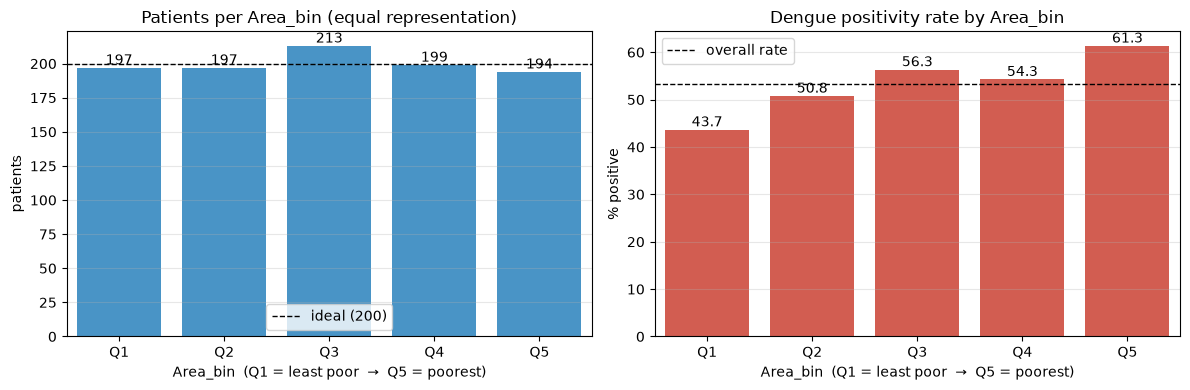

In [25]:
summary = (
    df.groupby("Area_bin", observed=False)
      .agg(n_patients=("Outcome", "size"), positive=("Outcome", "sum"), positive_rate=("Outcome", "mean"))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=summary.index, y=summary["n_patients"], ax=axes[0], color="#3498db")
axes[0].axhline(len(df) / 5, color="black", ls="--", lw=1, label="ideal (200)")
axes[0].set_title("Patients per Area_bin (equal representation)")
axes[0].set_ylabel("patients")
axes[0].legend()
axes[0].bar_label(axes[0].containers[0])

sns.barplot(x=summary.index, y=summary["positive_rate"] * 100, ax=axes[1], color="#e74c3c")
axes[1].axhline(df["Outcome"].mean() * 100, color="black", ls="--", lw=1, label="overall rate")
axes[1].set_title("Dengue positivity rate by Area_bin")
axes[1].set_ylabel("% positive")
axes[1].legend()
axes[1].bar_label(axes[1].containers[0], fmt="%.1f")

for ax in axes:
    ax.set_xlabel("Area_bin  (Q1 = least poor  →  Q5 = poorest)")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

display(summary.round(3))

I will keep both encodings for the modelling notebook to choose from:

* `Area_bin` — ordered categorical, robust, easy to read on a plot;
* `Area_HCR` — the raw poverty rate, in case a model prefers the continuous version.

Same goal as `Area_bin`, same machinery — but `Age` asks for one thing more. The bins must

When it comes to `Age`, it obviously should hold an equal number of patients in each bin, but also should add some change to dengue positivity rate in each bin. Otherwise, the binning is useless, just as the `Age` column itself. Second requirement is the main focus

In [26]:
# additional imports for this section
from itertools import combinations
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

SEED = 42

Before cutting anything, we look at the raw variable and at the positivity rate it produces.

Age: 8 - 65 | 58 distinct values | 0 missing
patients per single age year: min = 10  max = 24
correlation Age ~ Outcome: -0.0117


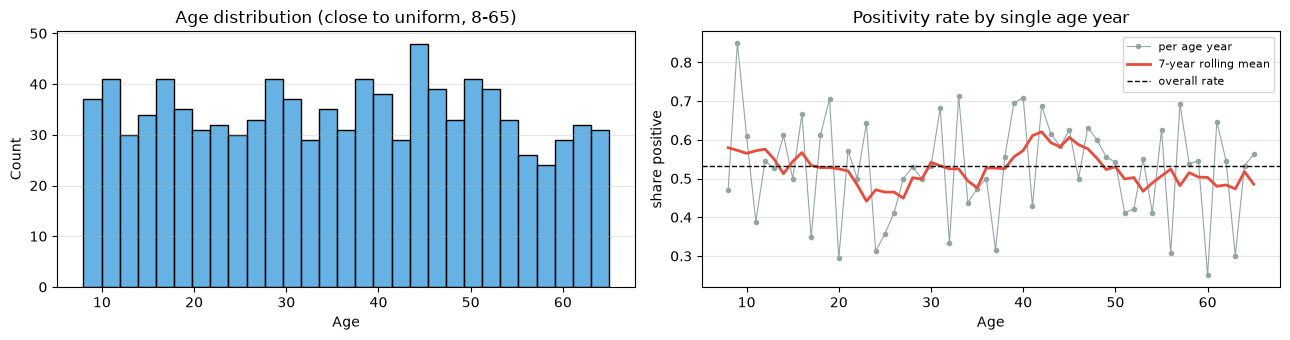

In [27]:
age_counts = (
    df.groupby("Age")
      .agg(n_patients=("Outcome", "size"), positive_rate=("Outcome", "mean"))
      .sort_index()
)

print("Age:", df["Age"].min(), "-", df["Age"].max(),
      "|", df["Age"].nunique(), "distinct values |", df["Age"].isnull().sum(), "missing")
print("patients per single age year: min =", age_counts["n_patients"].min(),
      " max =", age_counts["n_patients"].max())
print("correlation Age ~ Outcome:", round(np.corrcoef(df["Age"], df["Outcome"])[0, 1], 4))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

sns.histplot(df["Age"], bins=29, ax=axes[0], color="#3498db")
axes[0].set_title("Age distribution (close to uniform, 8-65)")

axes[1].plot(age_counts.index, age_counts["positive_rate"], marker=".", lw=0.8,
             color="#95a5a6", label="per age year")
axes[1].plot(age_counts.index,
             age_counts["positive_rate"].rolling(7, center=True, min_periods=3).mean(),
             color="#e74c3c", lw=2, label="7-year rolling mean")
axes[1].axhline(df["Outcome"].mean(), color="black", ls="--", lw=1, label="overall rate")
axes[1].set_title("Positivity rate by single age year")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("share positive")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

What we can notice from the graph is that the `Age` variable looks like uniform distribution. That means that it probably will be easier to create equal bins.

Second thing that can be noticed from the second graph is that there is no obvious trend in age vs positive cases graph (as we observed earlier).

At this point, it does not look like age binning will have any meaningful signal.

The age years are already ordered, so a binning is again just a choice of 4 cut positions.

4 bins for 58 age years give `C(57, 4) = 395 010` candidates instead of 52 360. At this point, the Python loop becomes slow, so the scoring is vectorised over all candidates at once with numpy.
* Besides the balance deviation, we also score each candidate with the **chi-square statistic** of the
  `bin x Outcome` table, i.e. how much the positivity rate moves between bins. `chi2 = 0` means all bins have
  exactly the same rate.

In [28]:
def enumerate_splits(n_groups, n_bins):
    """Every way of cutting an ordered list of `n_groups` groups into `n_bins` contiguous blocks.

    Returns an array of boundary positions, one row per candidate, e.g. [0, 12, 23, 34, 44, 58].
    """
    return np.array(
        [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
        dtype=np.int32,
    )


def score_splits(splits, group_sizes, group_positives):
    """Score every candidate split at once: sizes, positivity rates, balance deviation, chi-square.

    balance_deviation : largest distance of a bin from the ideal size  -> the Area_bin criterion
    chi2              : association between the binned feature and Outcome (0 = identical rates)
    """
    group_sizes = np.asarray(group_sizes, dtype=float)
    group_positives = np.asarray(group_positives, dtype=float)
    cum_n = np.concatenate([[0], group_sizes.cumsum()])
    cum_p = np.concatenate([[0], group_positives.cumsum()])

    n = np.diff(cum_n[splits], axis=1)                     # patients per bin
    p = np.diff(cum_p[splits], axis=1)                     # positives per bin
    total_n, total_p = group_sizes.sum(), group_positives.sum()
    target = total_n / (splits.shape[1] - 1)

    # chi-square of the bin x Outcome contingency table, for all candidates in one go
    expected_pos = n * total_p / total_n
    expected_neg = n * (total_n - total_p) / total_n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nan_to_num(
            (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
        ).sum(axis=1)

    rates = np.divide(p, n, out=np.full_like(p, np.nan), where=n > 0)
    return {
        "n": n,
        "rates": rates,
        "balance_deviation": np.abs(n - target).max(axis=1),
        "rate_spread": np.nanmax(rates, axis=1) - np.nanmin(rates, axis=1),
        "chi2": chi2,
    }


age_values = age_counts.index.values
age_sizes = age_counts["n_patients"].values
age_positives = df.groupby("Age")["Outcome"].sum().sort_index().values

splits = enumerate_splits(len(age_values), 5)
scores = score_splits(splits, age_sizes, age_positives)

print(f"{len(splits):,} candidate splits of {len(age_values)} age years into 5 bins")

395,010 candidate splits of 58 age years into 5 bins


First the exact analogue of what we did for `Area`: ignore the outcome and minimise the imbalance.

In [29]:
best_balance = scores["balance_deviation"].argmin()
b = splits[best_balance]

print("most balanced split:", [f"{age_values[b[i]]}-{age_values[b[i + 1] - 1]}" for i in range(5)])
print("  patients per bin :", scores["n"][best_balance].astype(int))
print("  positivity rate  :", np.round(scores["rates"][best_balance], 3))
print("  spread           :", round(scores["rate_spread"][best_balance] * 100, 1), "pp",
      " | chi2 =", round(scores["chi2"][best_balance], 2))

most balanced split: ['8-18', '19-30', '31-41', '42-52', '53-65']
  patients per bin : [201 199 196 209 195]
  positivity rate  : [0.557 0.487 0.546 0.56  0.513]
  spread           : 7.2 pp  | chi2 = 3.19


Patients per bin balance is 201 / 199 / 196 / 209 / 195, at worst **4.5 %** off the ideal 200

But the positivity rates are 55.7 / 48.7 / 54.6 / 56.0 / 51.3 %, a spread of only **7.2 pp** with no ordering to it, lower than 10% spread that I wanted initially

chi2 = 3.19 for 4 degrees of freedom (we have 5 age bins, two outcomes, so dof = (Age_bin - 1)(Outcome - 1) = (5 - 1)(4 - 1) = 4). That means that 3.19 is slightly lower than pure noise would have produced with p = 0.53.

instead of taking *the* most balanced split, let's try to accept **every split whose worst bin is within X % of the ideal 200 patients**, and among those pick the one with the largest chi-square.

In [30]:
rows = []
for tol_pct in [0, 5, 7.5, 10, 15, 20, 30]:
    tol = max(tol_pct / 100 * len(df) / 5, scores["balance_deviation"].min())
    allowed_ = np.where(scores["balance_deviation"] <= tol)[0]
    pick = allowed_[scores["chi2"][allowed_].argmax()]
    rows.append({
        "tolerance_%": tol_pct,
        "n_candidates": len(allowed_),
        "worst_bin_off_%": round(scores["balance_deviation"][pick] / (len(df) / 5) * 100, 1),
        "rate_spread_pp": round(scores["rate_spread"][pick] * 100, 1),
        "chi2": round(scores["chi2"][pick], 2),
        "sizes": str(scores["n"][pick].astype(int)),
        "bins": ", ".join(f"{age_values[splits[pick][i]]}-{age_values[splits[pick][i + 1] - 1]}"
                          for i in range(5)),
    })

display(pd.DataFrame(rows))

,tolerance_%,n_candidates,worst_bin_off_%,rate_spread_pp,chi2,sizes,bins
0,0.0,1,4.5,7.2,3.19,[201 199 196 209 195],"8-18, 19-30, 31-41, 42-52, 53-65"
1,5.0,1,4.5,7.2,3.19,[201 199 196 209 195],"8-18, 19-30, 31-41, 42-52, 53-65"
2,7.5,3,7.0,8.6,4.22,[201 199 196 190 214],"8-18, 19-30, 31-41, 42-51, 52-65"
3,10.0,21,9.0,10.7,6.39,[218 182 196 190 214],"8-19, 20-30, 31-41, 42-51, 52-65"
4,15.0,75,9.0,10.7,6.39,[218 182 196 190 214],"8-19, 20-30, 31-41, 42-51, 52-65"
5,20.0,262,20.0,13.2,10.40,[160 168 207 234 231],"8-16, 17-26, 27-38, 39-50, 51-65"
6,30.0,1241,28.5,15.1,11.11,[218 143 156 228 255],"8-19, 20-28, 29-37, 38-49, 50-65"


The table shows exactly what the trade costs:

* up to **10 %** tolerance the bins stay tight (worst bin 9 % off, i.e. 182–218 patients) and the spread grows
  from 7.2 pp to **10.7 pp**;
* past that, balance falls apart fast for very little extra signal — at 20 % the spread reaches 13.2 pp but
  the bins become 160 / 168 / 207 / 234 / 231, a 46 % gap between the smallest and the largest.

**10 % is the knee of the curve**, so that is the tolerance we take.

In [31]:
BALANCE_TOLERANCE = 0.10          # a bin may sit at most 10 % away from the ideal 200 patients

tol = BALANCE_TOLERANCE * len(df) / 5
allowed = np.where(scores["balance_deviation"] <= tol)[0]
chosen = allowed[scores["chi2"][allowed].argmax()]
age_bounds = splits[chosen]

# edges half-way between the last age of a bin and the first age of the next one
age_edges = [-np.inf] + [(age_values[b - 1] + age_values[b]) / 2 for b in age_bounds[1:-1]] + [np.inf]
age_labels = [f"{age_values[age_bounds[i]]}-{age_values[age_bounds[i + 1] - 1]}" for i in range(5)]

print("candidates within the tolerance:", len(allowed))
print("cut edges on Age:", age_edges[1:-1])
print("bin labels      :", age_labels)

df["Age_bin"] = pd.cut(df["Age"], bins=age_edges, labels=age_labels, ordered=True)

age_summary = (
    df.groupby("Age_bin", observed=False)
      .agg(n_patients=("Outcome", "size"), positive=("Outcome", "sum"), positive_rate=("Outcome", "mean"))
)
age_summary["share_%"] = (age_summary["n_patients"] / len(df) * 100).round(1)
age_summary["off_ideal_%"] = ((age_summary["n_patients"] - len(df) / 5).abs() / (len(df) / 5) * 100).round(1)
display(age_summary.round(3))

print("patients without a bin:", df["Age_bin"].isnull().sum())
print("worst bin:", age_summary["off_ideal_%"].max(), "% away from the ideal 200 patients")
print("positivity spread:",
      round((age_summary["positive_rate"].max() - age_summary["positive_rate"].min()) * 100, 1), "pp")

candidates within the tolerance: 21
cut edges on Age: [np.float64(19.5), np.float64(30.5), np.float64(41.5), np.float64(51.5)]
bin labels      : ['8-19', '20-30', '31-41', '42-51', '52-65']


,n_patients,positive,positive_rate,share_%,off_ideal_%
Age_bin,,,,,
8-19,218,124,0.569,21.8,9.0
20-30,182,85,0.467,18.2,9.0
31-41,196,107,0.546,19.6,2.0
42-51,190,109,0.574,19.0,5.0
52-65,214,108,0.505,21.4,7.0


patients without a bin: 0
worst bin: 9.0 % away from the ideal 200 patients
positivity spread: 10.7 pp


Both requirements are met on the sample:

| `Age_bin` | patients | off ideal | positivity |
|---|---|---|---|
| 8–19  | 218 | +9 % | 56.9 % |
| 20–30 | 182 | −9 % | 46.7 % |
| 31–41 | 196 | −2 % | 54.6 % |
| 42–51 | 190 | −5 % | 57.4 % |
| 52–65 | 214 | +7 % | 50.5 % |

Every bin holds between 182 and 218 patients, and the positivity rate moves over **10.7 pp**, dipping for
young adults (20–30) and peaking for 42–51 year olds. The cut points also happen to be readable age groups:
adolescents, young adults, adults, middle-aged, older adults.

I picked the cut points **using the outcome column**, out of a pool of 21 candidates — that is a form of target leakage. We can verify that this choice stays consistent and does not depend on the choice of the cut points.

In [ ]:
# classic chi-square test on the final bins
observed = pd.crosstab(df["Age_bin"], df["Outcome"])
chi2_stat, p_value, dof, _ = chi2_contingency(observed)
print(f"chi-square test Age_bin vs Outcome: chi2 = {chi2_stat:.2f}, dof = {dof}, p = {p_value:.3f}")

# how precise is each bin's rate? 95 % Wilson confidence intervals
low, high = proportion_confint(age_summary["positive"], age_summary["n_patients"], method="wilson")
ci = age_summary[["n_patients", "positive_rate"]].copy()
ci["ci_low"], ci["ci_high"] = low, high
display(ci.round(3))

chi-square test Age_bin vs Outcome: chi2 = 6.39, dof = 4, p = 0.172


,n_patients,positive_rate,ci_low,ci_high
Age_bin,,,,
8-19,218,0.569,0.502,0.633
20-30,182,0.467,0.396,0.539
31-41,196,0.546,0.476,0.614
42-51,190,0.574,0.503,0.642
52-65,214,0.505,0.438,0.571


In [ ]:
# Shuffle Outcome (destroying any age-outcome link), then let the search do its best again.
# If the real chi2 is not larger than what shuffled labels produce, the pattern is noise.
rng = np.random.default_rng(SEED)
age_codes = pd.Categorical(df["Age"], categories=age_values).codes
candidate_pool = splits[allowed]                 # the 21 splits the selection may choose from
group_sizes = np.bincount(age_codes, minlength=len(age_values)).astype(float)


def best_chi2_over_pool(outcome_values):
    """Largest chi-square the selection can reach for a given Outcome vector."""
    positives = np.bincount(age_codes, weights=outcome_values, minlength=len(age_values))
    return score_splits(candidate_pool, group_sizes, positives)["chi2"].max()


observed_chi2 = best_chi2_over_pool(df["Outcome"].values.astype(float))
null_chi2 = np.array([best_chi2_over_pool(rng.permutation(df["Outcome"].values).astype(float))
                      for _ in range(2000)])
perm_p = (np.sum(null_chi2 >= observed_chi2) + 1) / (len(null_chi2) + 1)

print(f"chi2 on the real labels     : {observed_chi2:.2f}")
print(f"chi2 on shuffled labels     : mean {null_chi2.mean():.2f}, "
      f"95th pct {np.percentile(null_chi2, 95):.2f}")
print(f"permutation p-value         : {perm_p:.3f}")

chi2 on the real labels     : 6.39
chi2 on shuffled labels     : mean 5.44, 95th pct 11.42
permutation p-value         : 0.308


* The chi-square test on the final bins gives `p = 0.17`, which is not significant even though the cut points were chosen to maximise exactly this statistic;
* the five confidence intervals overlap heavily (e.g. 20–30 is 39.6–53.9 %, 42–51 is 50.3–64.2 %);
* shuffling the labels and re-running the whole search reaches an average chi2 of 5.4 against our 6.4 — permutation `p = 0.31` (roughly one shuffled dataset in three does as well as the real one)

`Age` simply does not predict dengue positivity in this dataset, and no choice of cut points can manufacture that.

We can still keep `Age_bin` because:

1. it can give linear models a non-monotone representation of age
2. it costs one ordinal column (or 5 categorical ones)
3. `Age` is kept raw as well, so nothing is lost.

If `Age_bin` does not show itself worth in feature engineering section, we can just drop it

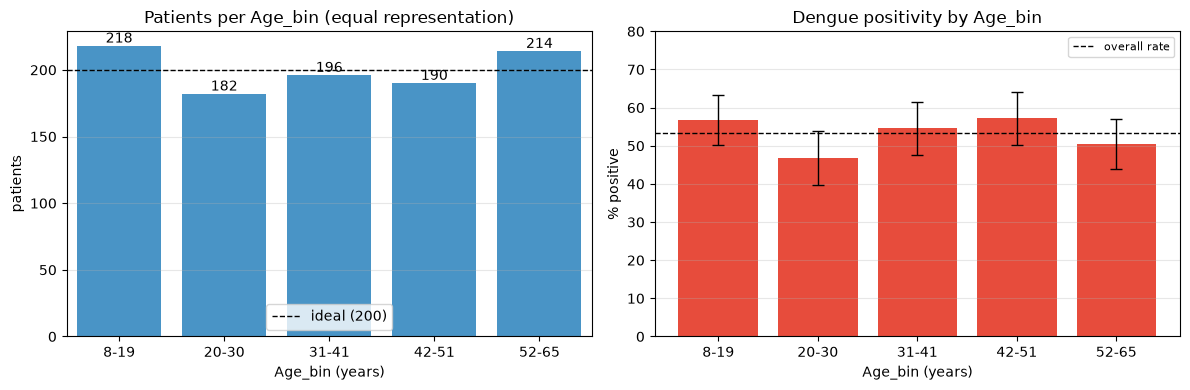

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=age_summary.index, y=age_summary["n_patients"], ax=axes[0], color="#3498db")
axes[0].axhline(len(df) / 5, color="black", ls="--", lw=1, label="ideal (200)")
axes[0].set_title("Patients per Age_bin (equal representation)")
axes[0].set_ylabel("patients")
axes[0].legend()
axes[0].bar_label(axes[0].containers[0])

axes[1].bar(age_summary.index.astype(str), age_summary["positive_rate"] * 100, color="#e74c3c")
axes[1].errorbar(np.arange(5), age_summary["positive_rate"] * 100,
                 yerr=[(age_summary["positive_rate"] - ci["ci_low"]) * 100,
                       (ci["ci_high"] - age_summary["positive_rate"]) * 100],
                 fmt="none", ecolor="black", capsize=4, lw=1)
axes[1].axhline(df["Outcome"].mean() * 100, color="black", ls="--", lw=1, label="overall rate")
axes[1].set_title("Dengue positivity by Age_bin")
axes[1].set_ylabel("% positive")
axes[1].set_ylim(0, 80)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Age_bin (years)")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

Bars do move, but every interval covers the overall 53.3 % line.